<a href="https://colab.research.google.com/github/Pratikshapawar-star/python-internship-practice-code/blob/main/Day11K_mean_Mall_Customers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data=pd.read_csv('/content/Mall_Customers.csv')

In [ ]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
data.shape

(200, 5)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


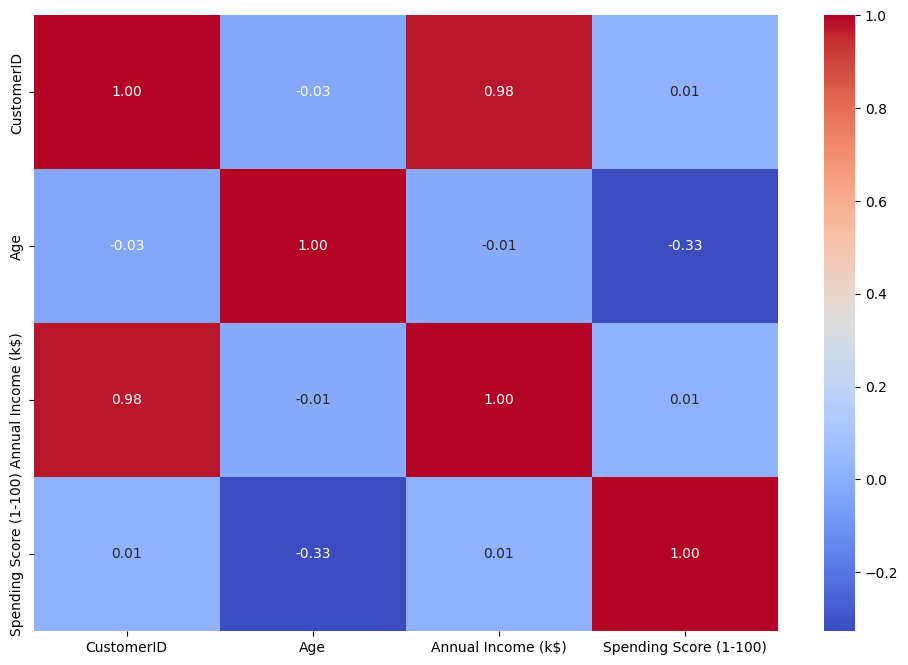

In [ ]:
from matplotlib import figure
numeric_data = data.select_dtypes(include=[np.number])
figure = plt.figure(figsize=(12, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt='.2f' )
plt.show()

In [ ]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(numeric_data)
print(pd.DataFrame(data_scaled, columns=numeric_data.columns).head())

   CustomerID       Age  Annual Income (k$)  Spending Score (1-100)
0   -1.723412 -1.424569           -1.738999               -0.434801
1   -1.706091 -1.281035           -1.738999                1.195704
2   -1.688771 -1.352802           -1.700830               -1.715913
3   -1.671450 -1.137502           -1.700830                1.040418
4   -1.654129 -0.563369           -1.662660               -0.395980


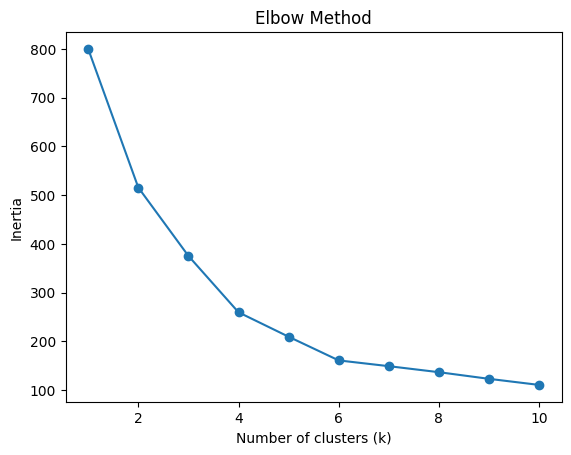

In [ ]:
inertia=[]
k_range = range(1,11)

for k in k_range:
  kmeans=KMeans(n_clusters=k, random_state=42)
  kmeans.fit(data_scaled)
  inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker="o")
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()

In [ ]:
k=3
kmeans=KMeans(n_clusters=k, random_state=42)
data['cluster']= kmeans.fit_predict(data_scaled)

print(data.head())

NameError: name 'KMeans' is not defined

In [ ]:
sil_score = silhouette_score(data_scaled, data['cluster'])
print('Silhouette Score: ', sil_score)

NameError: name 'silhouette_score' is not defined

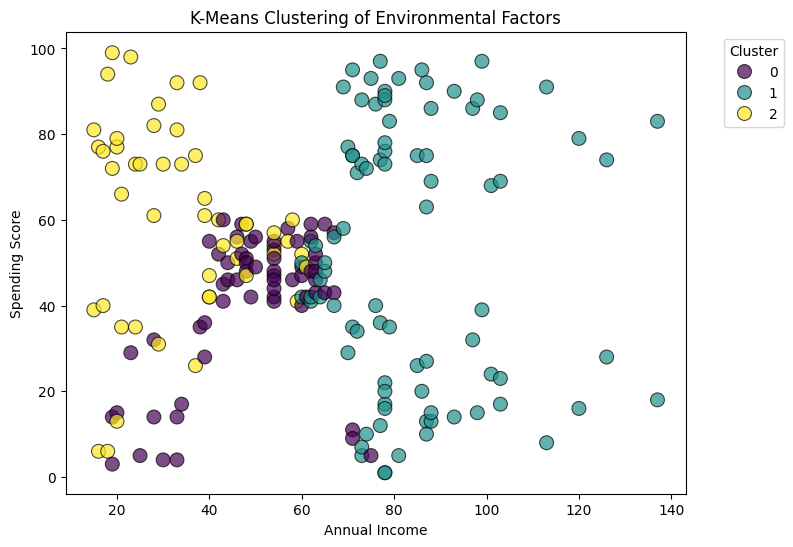

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='cluster', data=data, palette='viridis',s=100,alpha=0.7,edgecolor='k')

plt.title('K-Means Clustering of Environmental Factors')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend(title='Cluster',bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()